# 04_6 · Moderación jerárquica con modelos clásicos

Este cuaderno reproduce con modelos clásicos las dos arquitecturas jerárquicas de `04_4` y `04_5`:

1. **Cascada:** puerta binaria `SEGURO/daño` seguida por cinco clasificadores de daño entrenados con todos los daños y negativos seguros difíciles.
2. **Jerarquía compartida:** un TF-IDF común alimenta una cabeza binaria y cinco cabezas multietiqueta; el puntaje final es `p(daño) × p(categoría)`.

Para aislar el efecto de arquitectura, cada diseño se compara con un modelo plano de la misma familia, entrenado sobre exactamente los mismos datos ampliados. Como análisis secundario, el ganador se compara también con el SVM plano histórico de `04_2` sobre el mismo test 4:1.

In [1]:
from pathlib import Path
import sys

def find_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'scripts_auxiliares' / 'experimentos_jerarquicos_clasicos.py').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto.')

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import Image, Markdown, display
from scripts_auxiliares import experimentos_jerarquicos_clasicos as jc
print('Raíz:', ROOT)

Raíz: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4


## 1. Dataset ampliado sin fuga por video

Se propaga al dataset integrado completo el mapa `video_id → split` congelado por `04_2`. Así se aprovechan más de 100 mil seguros sin introducir videos de validación/test en entrenamiento. Los videos que no recibieron split se excluyen y quedan cuantificados.

In [2]:
context = jc.load_expanded_context()
display(jc.expanded_dataset_summary(context))
display({
    'chunks_integrados': context['audit']['integrated_rows'],
    'chunks_utilizables': context['audit']['mapped_rows'],
    'seguros_utilizables': context['audit']['usable_safe_total'],
    'daños_utilizables': context['audit']['usable_damage_total'],
    'seguros_sin_split_excluidos': context['audit']['unmapped_safe_rows_excluded'],
    'se_conservaron_todos_los_daños': context['audit']['all_damage_retained'],
})

,split,rows,videos,safe,damage,chunk_ids_sha256
0,train,80887,2086,75943,4944,a131611dfb6ba1cfcbaee0ee7cd53b5a8075a721af932e...
1,validation,17760,448,16682,1078,01b6b5f537a540022e3ffae16963f34eb7fb958e76586a...
2,test,17666,448,16625,1041,c0c15bea2772fad7bcae8986fee3d874ce7d7de388b7bf...


{'chunks_integrados': 117244,
 'chunks_utilizables': 116313,
 'seguros_utilizables': 109250,
 'daños_utilizables': 7063,
 'seguros_sin_split_excluidos': 931,
 'se_conservaron_todos_los_daños': True}

## 2. Modelos e hiperparámetros heredados

No se reinicia la búsqueda. Se reutilizan las configuraciones que ganaron la sección 2.2 de `04_2`:

- SVM lineal palabra+carácter: `C=0,25`, `min_df=1`, 50.000 features.
- Regresión logística: `C=2`, `min_df=2`, 50.000 features.
- fastText optimizado se reentrena únicamente como referencia plana adicional.

SVM y logística generan, cada uno, modelo plano, cascada y jerarquía compartida. Sus márgenes se calibran mediante sigmoide sobre predicciones out-of-fold de tres `GroupKFold` por video. Después de calibrar, la cabeza final se ajusta con todo `train`. Esto permite combinar puntajes como probabilidades sin consultar validación ni test durante la calibración.

Los modelos clásicos no usan épocas: cada optimizador converge según tolerancia o `max_iter`. Sólo se entrenan las cinco categorías gruesas; etiquetas finas y flags transversales no son features ni objetivos.

In [3]:
prior = jc.load_prior_hyperparameters()
display(prior['configurations'])
display(prior['fasttext_parameters'])
print('Fuente verificada:', prior['source'])

{'linear_svm_word_char': {'C': 0.25, 'min_df': 1, 'max_features': 50000},
 'logistic_regression': {'C': 2.0, 'min_df': 2, 'max_features': 50000}}

{'lr': 0.5,
 'epoch': 15,
 'wordNgrams': 2,
 'bucket': 200000,
 'dim': 50,
 'loss': 'ova'}

Fuente verificada: {'path': 'resultados\\metricas\\transformer_grueso\\comparacion_modelos_clasicos_optimizados.json', 'sha256': '08980319c249efca695b22300e3d87e4eeaa1cb3bc54dd64f25ff2817d4bc2e8', 'bytes': 23960}


## 3. Protocolo de comparación

La selección del mejor jerárquico y todos los umbrales usan exclusivamente `validation_expanded`. El test ampliado se reserva para la comparación final. PR-AUC macro es la métrica primaria; también se informan F1 macro, recall por categoría, recall de cualquier daño y falsos negativos.

Cada jerárquico se compara de forma pareada con el plano de su misma familia mediante 1.000 bootstrap de videos completos. Se declara mejora sólo si todo el IC 95 % de Δ PR-AUC macro es positivo y el límite superior de Δ tasa de falsos negativos no supera cero. La comparación histórica 4:1 se interpreta por separado porque combina el efecto de arquitectura y el de disponer de más negativos seguros.

In [4]:
FORCE = False
BOOTSTRAP_REPLICATES = 1_000
INCLUDE_FASTTEXT = True
display({
    'folds_calibracion_por_video': jc.CALIBRATION_FOLDS,
    'bootstrap_por_video': BOOTSTRAP_REPLICATES,
    'fastText_plano': INCLUDE_FASTTEXT,
    'recall_objetivo_puerta': jc.GATE_RECALL_TARGET,
})

{'folds_calibracion_por_video': 3,
 'bootstrap_por_video': 1000,
 'fastText_plano': True,
 'recall_objetivo_puerta': 0.97}

## 4. Entrenamiento

Las barras muestran la familia, colección de cabezas y progreso de calibración. Se guardan vectorizadores, cabezas calibradas, umbrales, probabilidades, tablas, bootstrap, gráficos e informe. Con `FORCE=False`, un resultado terminado y compatible se carga sin reentrenar.

In [5]:
result = jc.run_experiment(
    force=FORCE,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
    include_fasttext=INCLUDE_FASTTEXT,
)
print('Ganador por validación:', result['selection']['winner_label'])
print('Referencia plana pareada:', result['selection']['matched_flat_key'])
print('Resultado:', jc.RESULT_PATH)
print('Informe:', jc.REPORT_PATH)

[SVM lineal calibrado palabra+carácter] Ajustando TF-IDF con 80,887 chunks...
svm/puerta · calibración fold 1/3
svm/puerta · calibración fold 2/3
svm/puerta · calibración fold 3/3


svm/cabezas completas:   0%|          | 0/5 [00:00<?, ?cabeza/s]

svm/cabezas completas/RACISMO_DISCRIMINACION · calibración fold 1/3
svm/cabezas completas/RACISMO_DISCRIMINACION · calibración fold 2/3
svm/cabezas completas/RACISMO_DISCRIMINACION · calibración fold 3/3
svm/cabezas completas/ACOSO_GENERO_IDENTIDAD · calibración fold 1/3
svm/cabezas completas/ACOSO_GENERO_IDENTIDAD · calibración fold 2/3
svm/cabezas completas/ACOSO_GENERO_IDENTIDAD · calibración fold 3/3
svm/cabezas completas/ACOSO_PERSONAL · calibración fold 1/3
svm/cabezas completas/ACOSO_PERSONAL · calibración fold 2/3
svm/cabezas completas/ACOSO_PERSONAL · calibración fold 3/3
svm/cabezas completas/AMENAZA_DIRECTA · calibración fold 1/3
svm/cabezas completas/AMENAZA_DIRECTA · calibración fold 2/3
svm/cabezas completas/AMENAZA_DIRECTA · calibración fold 3/3
svm/cabezas completas/CONTENIDO_SEXUAL · calibración fold 1/3
svm/cabezas completas/CONTENIDO_SEXUAL · calibración fold 2/3
svm/cabezas completas/CONTENIDO_SEXUAL · calibración fold 3/3


svm/cabezas cascada:   0%|          | 0/5 [00:00<?, ?cabeza/s]

svm/cabezas cascada/RACISMO_DISCRIMINACION · calibración fold 1/3
svm/cabezas cascada/RACISMO_DISCRIMINACION · calibración fold 2/3
svm/cabezas cascada/RACISMO_DISCRIMINACION · calibración fold 3/3
svm/cabezas cascada/ACOSO_GENERO_IDENTIDAD · calibración fold 1/3
svm/cabezas cascada/ACOSO_GENERO_IDENTIDAD · calibración fold 2/3
svm/cabezas cascada/ACOSO_GENERO_IDENTIDAD · calibración fold 3/3
svm/cabezas cascada/ACOSO_PERSONAL · calibración fold 1/3
svm/cabezas cascada/ACOSO_PERSONAL · calibración fold 2/3
svm/cabezas cascada/ACOSO_PERSONAL · calibración fold 3/3
svm/cabezas cascada/AMENAZA_DIRECTA · calibración fold 1/3
svm/cabezas cascada/AMENAZA_DIRECTA · calibración fold 2/3
svm/cabezas cascada/AMENAZA_DIRECTA · calibración fold 3/3
svm/cabezas cascada/CONTENIDO_SEXUAL · calibración fold 1/3
svm/cabezas cascada/CONTENIDO_SEXUAL · calibración fold 2/3
svm/cabezas cascada/CONTENIDO_SEXUAL · calibración fold 3/3
[Regresión logística calibrada] Ajustando TF-IDF con 80,887 chunks...
log

...

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

Ganador por validación: SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta
Referencia plana pareada: svm__flat
Resultado: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\resultados\metricas\jerarquico_clasico\resultado.json
Informe: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\resultados\INFORME_EXPERIMENTO_JERARQUICO_CLASICO.md


## 5. Resultados y comparación

In [6]:
tables = jc.load_tables()
display(tables['comparison'].loc[
    tables['comparison']['split'].isin(['validation_expanded', 'test_expanded'])
].sort_values(['split', 'damage_pr_auc_macro'], ascending=[True, False]).round(4))
display(tables['bootstrap'].round(4))
print('Comparación secundaria con el plano histórico 04_2:')
display(tables['historical_bootstrap'].round(4))

,model_key,modelo,familia,diseno,split,exact_match,jaccard_samples,precision_micro,recall_micro,f1_micro,...,damage_pr_auc_macro,n,any_damage_prevalence,any_damage_prediction_rate,any_damage_precision,any_damage_recall,any_damage_f1,missed_damage_as_safe,category_false_negatives,minimum_category_recall
9,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,linear_svm_word_char,cascade,test_expanded,0.9165,0.9211,0.9088,0.9112,0.9100,...,0.2352,17666,0.0589,0.0559,0.3810,0.3612,0.3708,665,989,0.2072
1,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,0.9002,0.9048,0.8977,0.8947,0.8962,...,0.2306,17666,0.0589,0.0819,0.3269,0.4544,0.3802,568,924,0.1261
21,logistic__cascade,Regresión logística calibrada · Cascada binari...,logistic_regression,cascade,test_expanded,0.9137,0.9181,0.9058,0.9076,0.9067,...,0.2303,17666,0.0589,0.0586,0.3649,0.3631,0.3640,663,1007,0.1351
5,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,test_expanded,0.9101,0.9155,0.8955,0.9081,0.9017,...,0.2287,17666,0.0589,0.0635,0.3619,0.3900,0.3754,635,941,0.1712
13,logistic__flat,Regresión logística calibrada · Plano,logistic_regression,flat,test_expanded,0.9076,0.9119,0.9030,0.9015,0.9022,...,0.2282,17666,0.0589,0.0713,0.3455,0.4179,0.3783,606,952,0.2072
17,logistic__shared_hierarchy,Regresión logística calibrada · Jerárquico clá...,logistic_regression,shared_hierarchy,test_expanded,0.9151,0.9202,0.8999,0.9118,0.9058,...,0.2225,17666,0.0589,0.0561,0.3835,0.3650,0.3740,661,978,0.1441
25,fasttext__flat,fastText supervisado OVA · Plano,fasttext_supervised_ova,flat,test_expanded,0.9202,0.9234,0.9167,0.9107,0.9137,...,0.1672,17666,0.0589,0.0449,0.3615,0.2757,0.3128,754,1103,0.1351
0,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,0.8957,0.9014,0.8922,0.8916,0.8919,...,0.2602,17760,0.0607,0.0887,0.3321,0.4852,0.3943,555,916,0.3021
8,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,linear_svm_word_char,cascade,validation_expanded,0.9158,0.9210,0.9063,0.9110,0.9086,...,0.2586,17760,0.0607,0.0618,0.4075,0.4147,0.4110,631,966,0.2974
20,logistic__cascade,Regresión logística calibrada · Cascada binari...,logistic_regression,cascade,validation_expanded,0.9119,0.9168,0.9027,0.9066,0.9046,...,0.2513,17760,0.0607,0.0653,0.3840,0.4128,0.3979,633,983,0.2697


,candidate_key,flat_reference_key,metrica,plano_test,experimento_test,delta_experimento_menos_plano,ic95_inferior,ic95_superior,replicas_validas
0,svm__cascade,svm__flat,pr_auc_macro,0.2306,0.2352,0.0046,-0.0061,0.0152,1000
1,svm__cascade,svm__flat,f1_macro,0.2929,0.2910,-0.0019,-0.0198,0.0150,1000
2,svm__cascade,svm__flat,any_damage_recall,0.4544,0.3612,-0.0932,-0.1175,-0.0698,1000
3,svm__cascade,svm__flat,false_negative_rate,0.5456,0.6388,0.0932,0.0698,0.1175,1000
4,svm__shared_hierarchy,svm__flat,pr_auc_macro,0.2306,0.2287,-0.0019,-0.0110,0.0090,1000
5,svm__shared_hierarchy,svm__flat,f1_macro,0.2929,0.2883,-0.0046,-0.0186,0.0093,1000
6,svm__shared_hierarchy,svm__flat,any_damage_recall,0.4544,0.3900,-0.0644,-0.0813,-0.0451,1000
7,svm__shared_hierarchy,svm__flat,false_negative_rate,0.5456,0.6100,0.0644,0.0451,0.0813,1000
8,logistic__cascade,logistic__flat,pr_auc_macro,0.2282,0.2303,0.0022,-0.0092,0.0109,1000
9,logistic__cascade,logistic__flat,f1_macro,0.2914,0.2690,-0.0224,-0.0394,-0.0071,1000


Comparación secundaria con el plano histórico 04_2:


,candidate_key,flat_reference_key,metrica,plano_test,experimento_test,delta_experimento_menos_plano,ic95_inferior,ic95_superior,replicas_validas
0,svm__cascade,svm_flat_historical_04_2,pr_auc_macro,0.4174,0.4037,-0.0137,-0.0289,-0.0009,1000
1,svm__cascade,svm_flat_historical_04_2,f1_macro,0.4517,0.3664,-0.0853,-0.1109,-0.0589,1000
2,svm__cascade,svm_flat_historical_04_2,any_damage_recall,0.6302,0.3612,-0.2690,-0.2966,-0.2406,1000
3,svm__cascade,svm_flat_historical_04_2,false_negative_rate,0.3698,0.6388,0.2690,0.2406,0.2966,1000


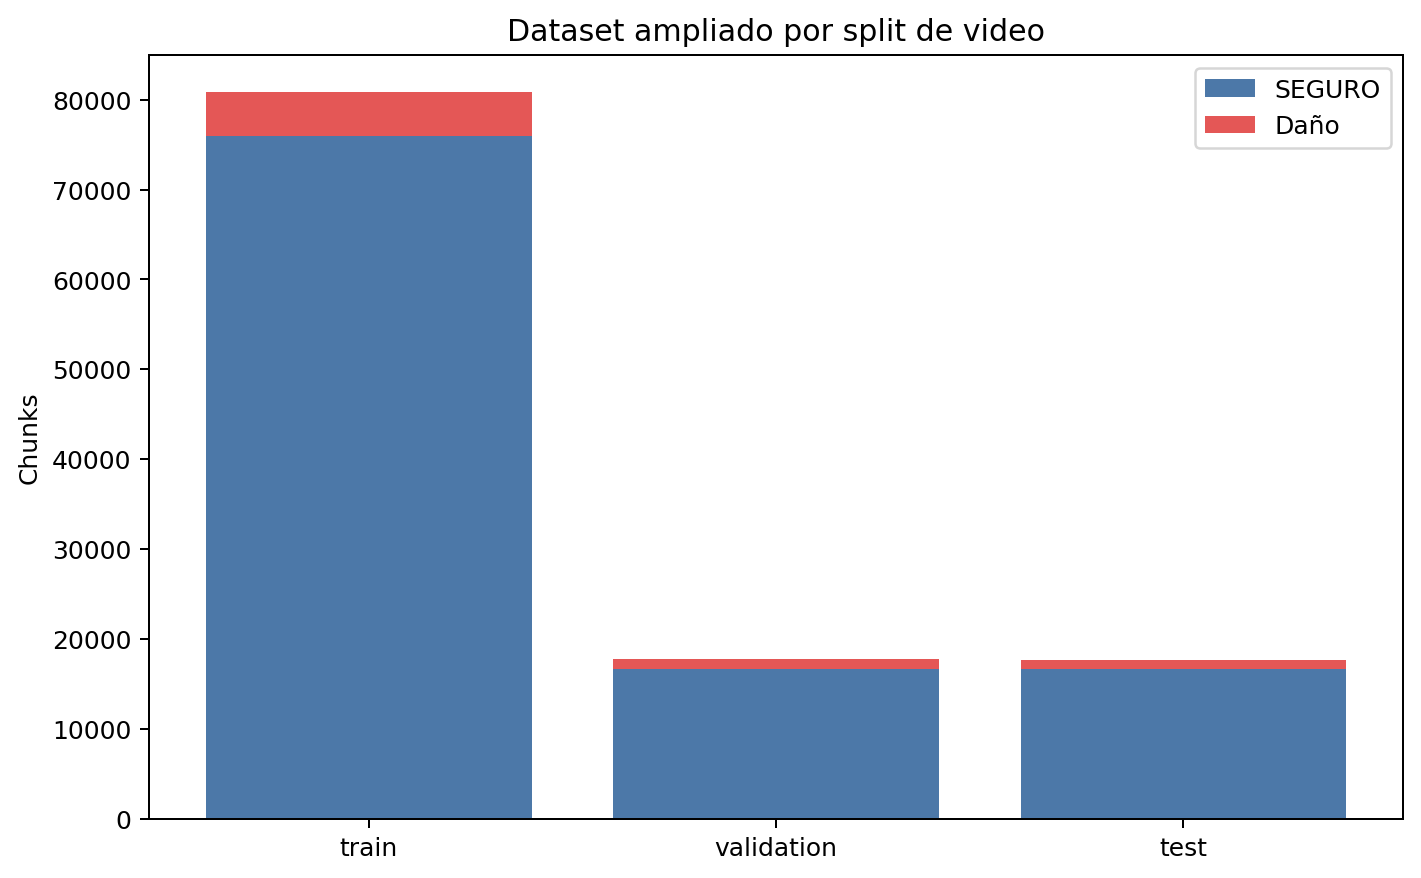

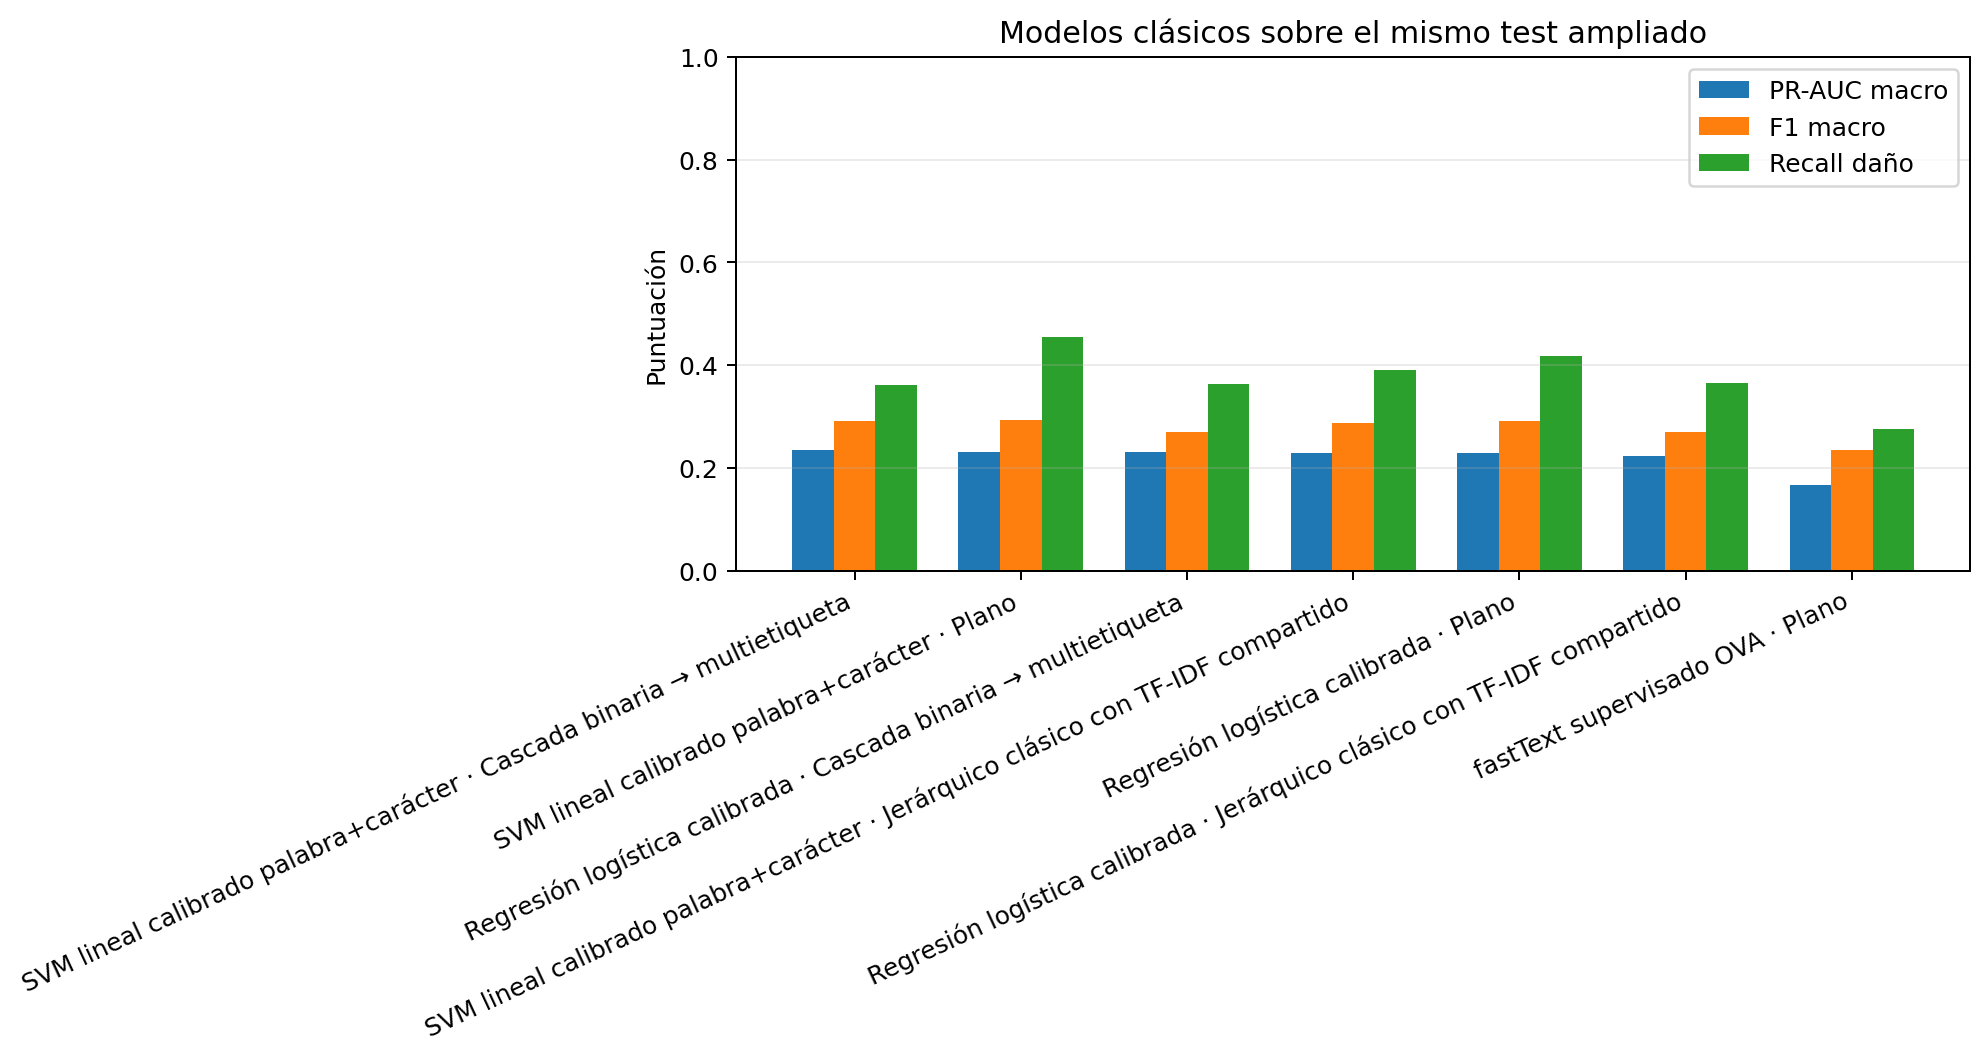

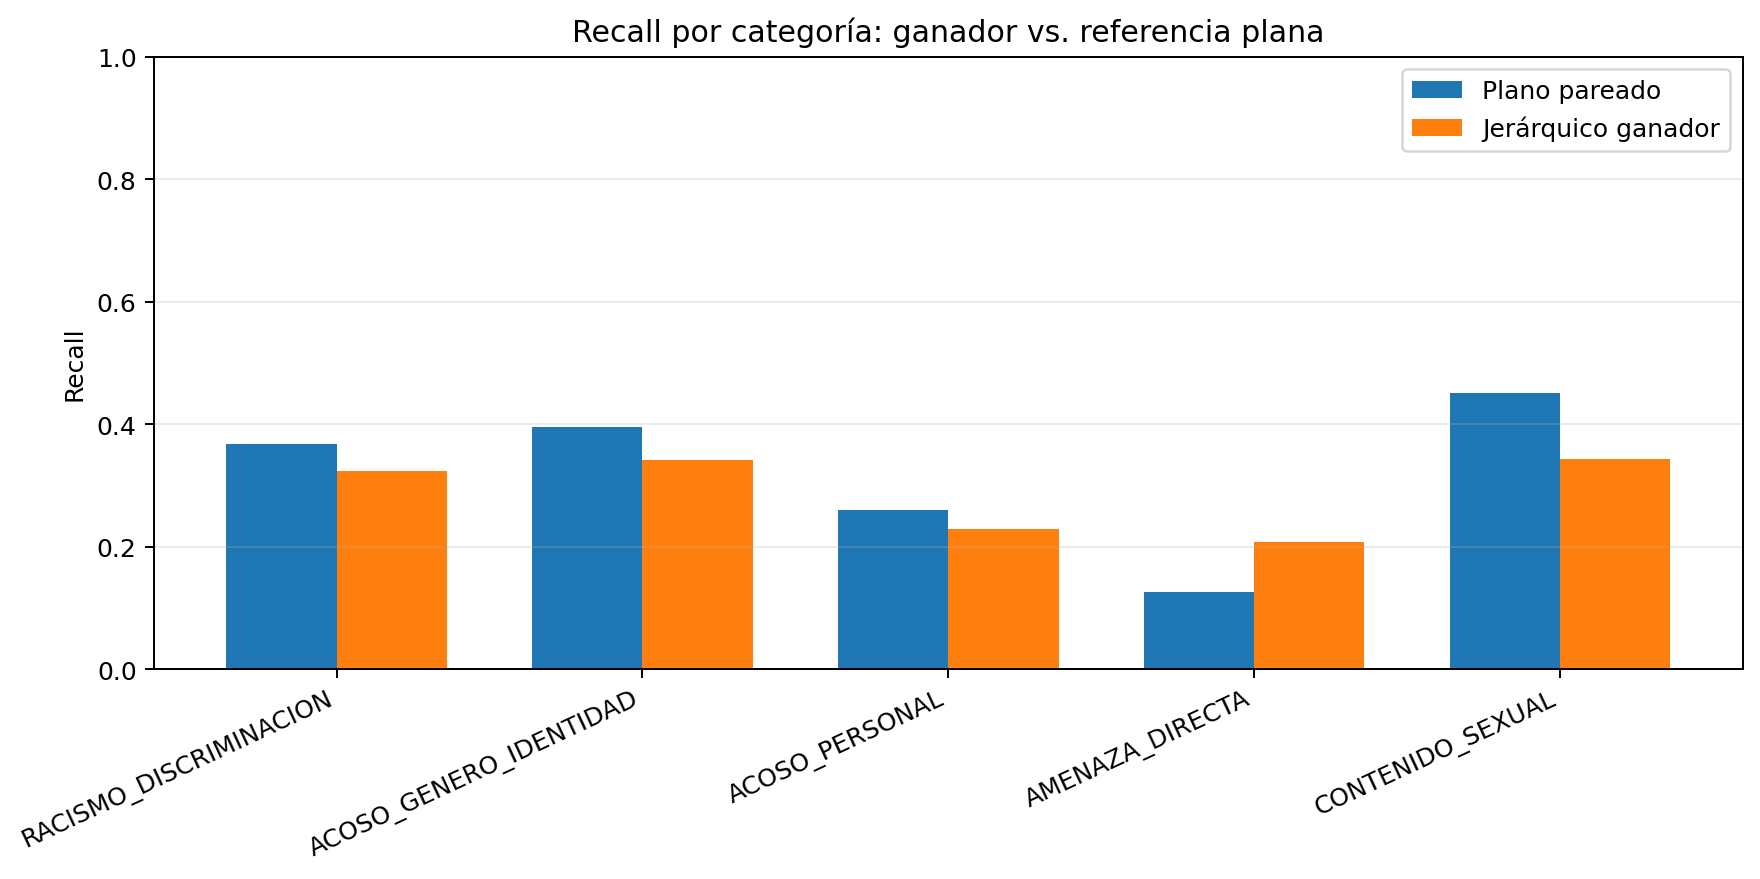

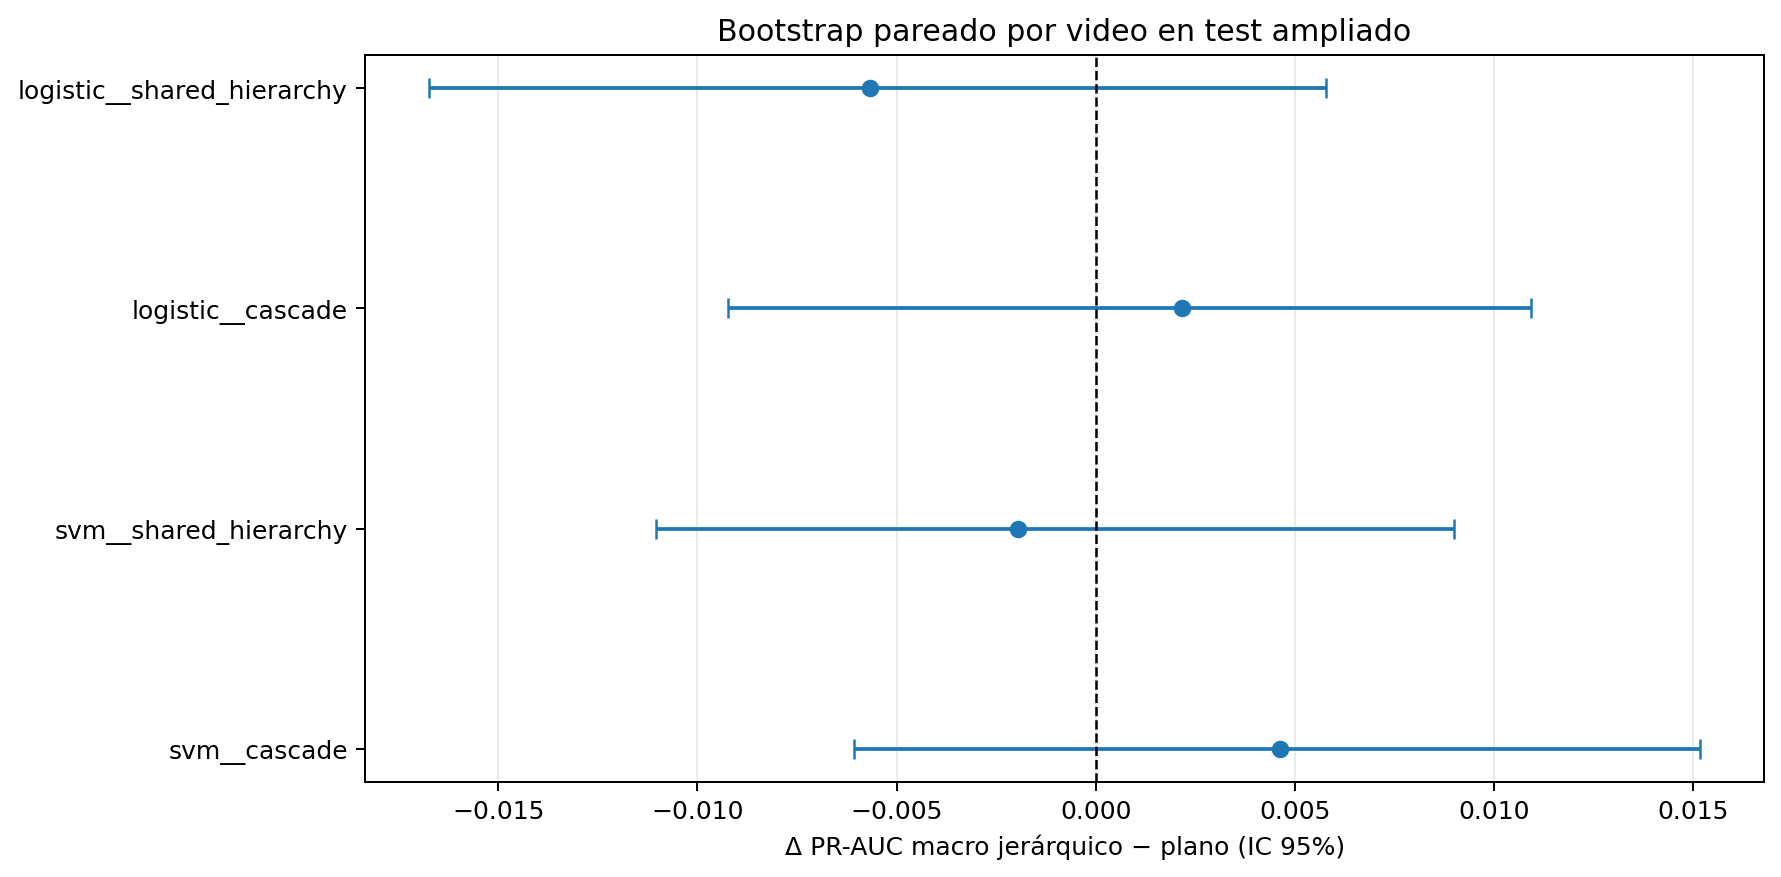

In [7]:
for name in (
    'dataset_ampliado_por_split.png',
    'comparacion_global_test_ampliado.png',
    'recall_ganador_vs_plano.png',
    'bootstrap_pr_auc_jerarquicos.png',
):
    display(Image(filename=str(jc.FIGURE_DIR / name)))

## 6. Abstención y conclusión reproducible

In [8]:
winner_key = result['selection']['winner_key']
winner = result['models'][winner_key]
display({
    'ganador': result['selection']['winner_label'],
    'decision_vs_plano_pareado': result['selection']['paired_decision']['status'],
    'reemplazar_plano_pareado':
        result['selection']['paired_decision']['replace_flat_model'],
    'decision_vs_svm_historico_04_2':
        result['historical_04_2_comparison']['decision']['status'],
    'operacion_selectiva_test':
        winner.get('selective_operation', {}).get('test'),
})
display(Markdown(jc.REPORT_PATH.read_text(encoding='utf-8')))

{'ganador': 'SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta',
 'decision_vs_plano_pareado': 'diferencia_inconclusa_con_este_test',
 'reemplazar_plano_pareado': False,
 'decision_vs_svm_historico_04_2': 'modelo_plano_superior_en_pr_auc_macro',
 'operacion_selectiva_test': {'n': 17666,
  'auto_safe_rows': 5511,
  'auto_damage_rows': 0,
  'review_rows': 12155,
  'automatic_coverage': 0.3119551681195517,
  'review_rate': 0.6880448318804483,
  'damage_sent_to_review_or_auto_damage_recall': 0.9663784822286263,
  'damage_automatic_safe_false_negatives': 35,
  'damage_automatic_safe_false_negative_rate': 0.03362151777137368,
  'safe_sent_to_review': 11149,
  'low_auto_safe_threshold': 0.025780204684734465,
  'high_auto_damage_threshold': 0.9767091067437927}}

# Experimento jerárquico clásico con SEGURO ampliado

Fecha: 2026-07-27T13:41:32-05:00

## Diseño y datos

El mapa `train/validation/test` de `04_2` se propagó por `video_id` al dataset integrado completo. Se utilizaron **116,313 chunks**, incluidos **109,250 SEGURO** y **7,063 con daño**. Train contiene 75,943 seguros y 4,944 daños. Se excluyeron 931 seguros de 248 videos sin asignación; no se perdió ningún daño.

Se reutilizaron los hiperparámetros ganadores de `04_2`: SVM lineal palabra+carácter (`C=0,25`, `min_df=1`, 50.000 features) y regresión logística (`C=2`, `min_df=2`, 50.000 features). Cada familia compara, sobre el mismo TF-IDF y datos, un modelo plano, una cascada y una jerarquía de cabezas compartidas. fastText se reentrenó como referencia plana adicional.

Los márgenes de SVM y logística se calibraron con regresión sigmoide sobre predicciones out-of-fold de tres `GroupKFold` por video. Épocas no aplican a estos optimizadores convexos: cada ajuste converge según su tolerancia o `max_iter`. Umbrales, selección del ganador y abstención usan sólo validación.

## Resultados en test ampliado

| Modelo | PR-AUC macro | F1 macro | Recall daño | Daños como seguro |
|---|---:|---:|---:|---:|
| SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta | 0.2352 | 0.2910 | 0.3612 | 665 |

| SVM lineal calibrado palabra+carácter · Plano | 0.2306 | 0.2929 | 0.4544 | 568 |

| Regresión logística calibrada · Cascada binaria → multietiqueta | 0.2303 | 0.2690 | 0.3631 | 663 |

| SVM lineal calibrado palabra+carácter · Jerárquico clásico con TF-IDF compartido | 0.2287 | 0.2883 | 0.3900 | 635 |

| Regresión logística calibrada · Plano | 0.2282 | 0.2914 | 0.4179 | 606 |

| Regresión logística calibrada · Jerárquico clásico con TF-IDF compartido | 0.2225 | 0.2691 | 0.3650 | 661 |

| fastText supervisado OVA · Plano | 0.1672 | 0.2339 | 0.2757 | 754 |

## Diferencias pareadas frente al plano de la misma familia

| Candidato | Métrica | Δ jerárquico − plano | IC 95 % por video |
|---|---|---:|---:|
| svm__cascade | pr_auc_macro | +0.0046 | [-0.0061, +0.0152] |

| svm__cascade | f1_macro | -0.0019 | [-0.0198, +0.0150] |

| svm__cascade | any_damage_recall | -0.0932 | [-0.1175, -0.0698] |

| svm__cascade | false_negative_rate | +0.0932 | [+0.0698, +0.1175] |

| svm__shared_hierarchy | pr_auc_macro | -0.0019 | [-0.0110, +0.0090] |

| svm__shared_hierarchy | f1_macro | -0.0046 | [-0.0186, +0.0093] |

| svm__shared_hierarchy | any_damage_recall | -0.0644 | [-0.0813, -0.0451] |

| svm__shared_hierarchy | false_negative_rate | +0.0644 | [+0.0451, +0.0813] |

| logistic__cascade | pr_auc_macro | +0.0022 | [-0.0092, +0.0109] |

| logistic__cascade | f1_macro | -0.0224 | [-0.0394, -0.0071] |

| logistic__cascade | any_damage_recall | -0.0548 | [-0.0786, -0.0308] |

| logistic__cascade | false_negative_rate | +0.0548 | [+0.0308, +0.0786] |

| logistic__shared_hierarchy | pr_auc_macro | -0.0057 | [-0.0167, +0.0058] |

| logistic__shared_hierarchy | f1_macro | -0.0223 | [-0.0369, -0.0077] |

| logistic__shared_hierarchy | any_damage_recall | -0.0528 | [-0.0728, -0.0331] |

| logistic__shared_hierarchy | false_negative_rate | +0.0528 | [+0.0331, +0.0728] |

El ganador se fijó con validación: **SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta**. Decisión frente a su plano pareado: **`diferencia_inconclusa_con_este_test`**. Comparación secundaria frente al SVM histórico de `04_2` sobre el mismo test 4:1: **`modelo_plano_superior_en_pr_auc_macro`**.

No se autoriza moderación autónoma: el test sigue siendo retrospectivo, con etiquetas mayormente asistidas por LLM y sin prevalencia prospectiva de producción.

## Artefactos

- Resultado: `resultados\metricas\jerarquico_clasico\resultado.json`
- Comparación: `resultados\metricas\jerarquico_clasico\comparacion_modelos.csv`
- Bootstrap: `resultados\metricas\jerarquico_clasico\bootstrap_pareado_por_video.csv`
- Modelos: `modelos\jerarquico_clasico`
- Figuras: `resultados\figuras\jerarquico_clasico`

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Joulin, A., Grave, E., Bojanowski, P., & Mikolov, T. (2017). Bag of tricks for efficient text classification. In *Proceedings of the 15th Conference of the European Chapter of the Association for Computational Linguistics: Volume 2, Short Papers* (pp. 427–431). Association for Computational Linguistics. https://aclanthology.org/E17-2068/

Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. In *Proceedings of the 22nd International Conference on Machine Learning* (pp. 625–632). ACM. https://doi.org/10.1145/1102351.1102430

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432


No hubo una mejora suficientemente respaldada frente al modelo plano. La cascada SVM obtuvo el mejor PR-AUC entre las alternativas jerárquicas, pero perdió demasiado recall y aumentó significativamente los falsos negativos.

## Ganador jerárquico

**SVM lineal calibrado palabra+carácter + cascada binaria → multietiqueta.**

Fue seleccionado sólo con validación:

- PR-AUC macro: 0,2586.
- F1 macro de daño: 0,3372.
- Sin embargo, el SVM plano obtuvo mayor PR-AUC en validación: 0,2602.

Por tanto, ganó entre los jerárquicos, pero no superó claramente al modelo plano.

## Resultados en test ampliado

| Métrica | SVM plano | SVM cascada | Diferencia |
|---|---:|---:|---:|
| PR-AUC macro | 0,2306 | **0,2352** | +0,0046 |
| F1 macro | **0,2929** | 0,2910 | −0,0019 |
| Precisión micro de daño | 0,2726 | **0,2946** | +0,0220 |
| Recall micro de daño | **0,3400** | 0,2936 | −0,0464 |
| Recall de cualquier daño | **0,4544** | 0,3612 | −0,0932 |
| F1 de cualquier daño | **0,3802** | 0,3708 | −0,0094 |
| Daños clasificados como seguro | **568** | 665 | +97 |
| FN totales de categorías | **924** | 989 | +65 |

La cascada incrementó algo la precisión, pero a costa de perder aproximadamente 9,3 puntos porcentuales de recall de daño.

## Inferencia estadística

Para PR-AUC macro:

```text
Δ cascada − plano = +0,0046
IC 95 % = [−0,0061, +0,0152]
```

El intervalo contiene cero: la mejora de PR-AUC es inconclusa.

Para la tasa de falsos negativos:

```text
Δ = +0,0932
IC 95 % = [+0,0698, +0,1175]
```

Aquí el resultado sí es concluyente: la cascada aumenta los falsos negativos entre 7,0 y 11,8 puntos porcentuales.

## Recall de la cascada por categoría

| Categoría | Recall | PR-AUC | Falsos negativos |
|---|---:|---:|---:|
| Racismo/discriminación | 0,3242 | 0,2545 | 173 |
| Acoso por género/identidad | 0,3422 | 0,2281 | 173 |
| Acoso personal | 0,2299 | 0,1731 | 335 |
| Amenaza directa | 0,2072 | 0,1305 | 88 |
| Contenido sexual | 0,3433 | 0,3901 | 220 |

La cascada mejoró especialmente `AMENAZA_DIRECTA` frente al plano —recall 0,207 frente a 0,126—, pero empeoró las otras cuatro categorías.

## Comparación con el SVM histórico de `04_2`

Sobre el mismo test 4:1:

| Métrica | SVM plano histórico | Nueva cascada |
|---|---:|---:|
| PR-AUC macro | **0,4174** | 0,4037 |
| F1 macro | **0,4517** | 0,3664 |
| Recall de daño | **0,6302** | 0,3612 |

El SVM plano histórico es claramente superior. Incluso la diferencia de PR-AUC favorece estadísticamente al plano: IC 95 % de la diferencia `cascada − plano` = [−0,0289, −0,0009].

## Conclusión

- Mejor estructura jerárquica: **cascada con SVM calibrado**.
- Mejor modelo defendible: **SVM plano**.
- Las estructuras jerárquicas no mejoraron globalmente el desempeño.
- Incorporar muchos seguros elevó precisión y exactitud aparente, pero redujo demasiado el recall.
- No debe sustituirse el modelo plano.
- Tampoco es apropiado como moderador autónomo.

Como sistema de alerta, la cascada puede conservar 96,64 % del daño, pero tendría que enviar **68,80 % de todos los chunks a revisión humana**, por lo que su ahorro operativo sería reducido.

Los resultados completos están en [resultado.json](D:/trabajo_PLN/Trabajo_PLN-MIA-Grupo4/resultados/metricas/jerarquico_clasico/resultado.json) y [INFORME_EXPERIMENTO_JERARQUICO_CLASICO.md](D:/trabajo_PLN/Trabajo_PLN-MIA-Grupo4/resultados/INFORME_EXPERIMENTO_JERARQUICO_CLASICO.md).

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Joulin, A., Grave, E., Bojanowski, P., & Mikolov, T. (2017). Bag of tricks for efficient text classification. In *Proceedings of the 15th Conference of the European Chapter of the Association for Computational Linguistics: Volume 2, Short Papers* (pp. 427–431). Association for Computational Linguistics. https://aclanthology.org/E17-2068/

Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. In *Proceedings of the 22nd International Conference on Machine Learning* (pp. 625–632). ACM. https://doi.org/10.1145/1102351.1102430

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432